## Background Info on Diabetes

Diabetes is one of the most prevalent chronic diseases in the United States and affects millions of individuals thus placing a significant burden on the healthcare system.

This diease is characterized by the body's inability to properly regulate blood glucose levels, which is either because of insufifcient insulin production or reduced insulin sensitivity. Over time, unmanaged diabetes can lead to very serious complications like cardiovascular diases, kidney failure, vision loss, and reduced life expectancy. Becasue so many individuals are unaware that they are at risk, early identification is important for implementing preventative strategies like lifestyle changes and medical intervention.

The dataset used in this project is derived from the Behavioral Risk Factor Surveillance System (BRFSS), a large scale health survey conducted anually by the CDC. It includes self-reported information on health behaviors, chronic conditions, and demographic factors. The version used in this analysis contains over 70,000 observations and includes key indicators like body mass index (BMI), physical activity, smoking status, and history of conditions like high blood pressure and heart diseases. These variables paint a picture of individual health profiles and are perfect for predictive modeling.

For this analysis, we use a cleaned and preprocessed subset of the data that includes 21 relevant health indicators.

Specifically, we use the balanced binary version of the dataset, which has the target variable indicating whether an individual has diabetes or is at risk (including prediabetes). This version was selected over the original multiclass dataset because it provides a balanced class distribution, which improves the performance and interpretability of our classification models. Using a binary outcome also simplifies evaluation metrics and allows for clearer interpretation of results.

## Research Question
The goal of this project is to investigate whether patterns in health-related behaviors and conditions can be used to accurately predict diabetes risk.

So we ask: **Can clustering individuals into health-risk profiles using k-Means improve the performance and interpretability of a kNN model in predicting diabetes?**

In order to answer the questions, we first use k-Means clustering to identify groups of individuals with similar health characteristics. Then we apply k-Nearest Neighbors (kNN), a supervised learning method, to predict whether an individual has diabetes based on these features. Finally, we evaluate whether incorporating cluster membership as an extra feature improves the predicting performance.


## Data Science Lifecycle Phase 1

This part of the project is a part of phase 1, which is where we develop an idea, gather data, bussiness understanding, and evulation criteria. We knew that we wanted our project to focus on something medical, therefore we started formulating questions that we would be interested working on. As we were searching for data sets we realized that most of the health, medicial and hospital data sets were about diseases. We took a look at a few before we decided that the diabetes data was the best for our project. This topic is interesting to us and as we looked over the data set we quickly saw that we would be able to use K-means and knn models to try and predict whether there are any variables that could help us predict diabetes for individuals.


In [ ]:
# IMPORTS:
# from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# For cluster evaluation
from sklearn.metrics import silhouette_score

In [ ]:
# Importing our dataset
# using: diabetes_binary_5050split_health_indicators_BRFSS2015.csv

# Reason:
# 1. Binary classification (0 = no diabetes, 1 = prediabetes/diabetes)
# 2. Balanced dataset (50/50 split)
# 3. Better for kNN and evaluation (accuracy, ROC-AUC)

from google.colab import files
uploaded = files.upload()

df = pd.read_csv("diabetes_binary_5050split_health_indicators_BRFSS2015.csv")

Saving diabetes_binary_5050split_health_indicators_BRFSS2015.csv to diabetes_binary_5050split_health_indicators_BRFSS2015.csv


## Initial Data Inspection

In [ ]:
# View dataset dimensions (rows, columns)
df.shape

(70692, 22)

In [ ]:
# Preview first few rows to understand structure
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [ ]:
# Display column names, data types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [ ]:
# Double checking there's no null values
df.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [ ]:
# Summary statistics for all variables
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


### Interpretation

The dataset contains 70,692 observations and 22 variables, including the target variable Diabetes_binary. All variables are numeric, with most representing binary indicators (0 or 1), while a few variables such as BMI, Age, GenHlth, MentHlth, and PhysHlth are continuous or ordinal.

There are no missing values in the dataset, which simplifies our preprocessing. The target variable has a mean of 0.5, confirming that the dataset is balanced between individuals with and without diabetes risk.

This balance is really good for  classification models because it prevents bias towards one class.

In [ ]:
# Convert all columns to integer type

# Some variables are binary but stores as floats
# Converting to integer will ensure consistency across features

df = df.astype(int)

# Confirm updates data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Diabetes_binary       70692 non-null  int64
 1   HighBP                70692 non-null  int64
 2   HighChol              70692 non-null  int64
 3   CholCheck             70692 non-null  int64
 4   BMI                   70692 non-null  int64
 5   Smoker                70692 non-null  int64
 6   Stroke                70692 non-null  int64
 7   HeartDiseaseorAttack  70692 non-null  int64
 8   PhysActivity          70692 non-null  int64
 9   Fruits                70692 non-null  int64
 10  Veggies               70692 non-null  int64
 11  HvyAlcoholConsump     70692 non-null  int64
 12  AnyHealthcare         70692 non-null  int64
 13  NoDocbcCost           70692 non-null  int64
 14  GenHlth               70692 non-null  int64
 15  MentHlth              70692 non-null  int64
 16  Phys

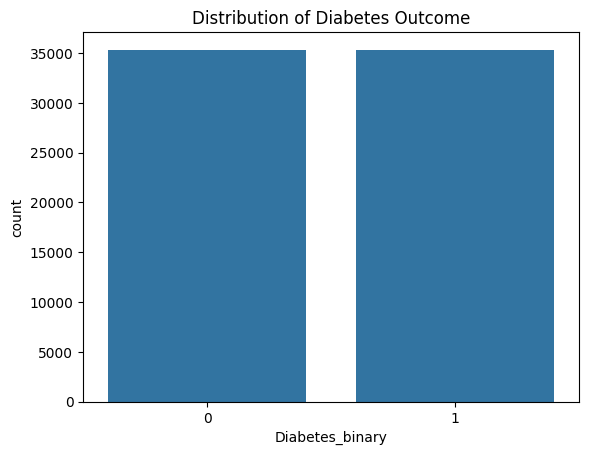

In [ ]:
# Target Variable Distribution

# Visualization distribution of target variable

# Count of each class ( 0 = no diabetes & 1 = diabetes/prediabetes)
sns.countplot(x="Diabetes_binary", data=df)

# Adds title
plt.title("Distribution of Diabetes Outcome")

# Displays plot
plt.show()

**Interpretation**

The target variable is evenly distributed between the two classes, confirming that the dataset is balanced. This is important because it allows classification models to learn both classes equally and ensures that evaluation metrics such as accuracy and ROC-AUC are meaningful.

## BMI and Diabetes Relationship

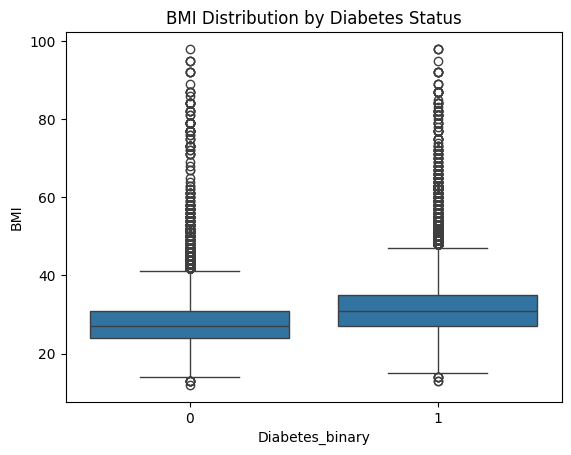

In [ ]:
# Analyze relationship between BMI and diabetes
# This plot compares the distribution of BMI between individuals
# with and without diabetes risk.

# Boxplot comparing BMI distributions across diabetes classes
sns.boxplot(x='Diabetes_binary', y='BMI', data=df)

# Add title
plt.title("BMI Distribution by Diabetes Status")

# Display plot
plt.show()

**Interpretation**

The distribution shows that individuals with diabetes (class 1) tend to have higher BMI values compared to those without diabetes (class 0). The median BMI for the diabetes group is noticeably higher, and the upper range of BMI values is also more extreme.

There is also a wider spread in BMI among individuals with diabetes, suggesting greater variability in this group. While both groups contain outliers, the concentration of higher BMI values is more prominent in the diabetes group.

This supports the established relationship between obesity and diabetes risk, indicating that BMI is likely to be a strong predictor in the model.

## Age and Diabetes Relationship

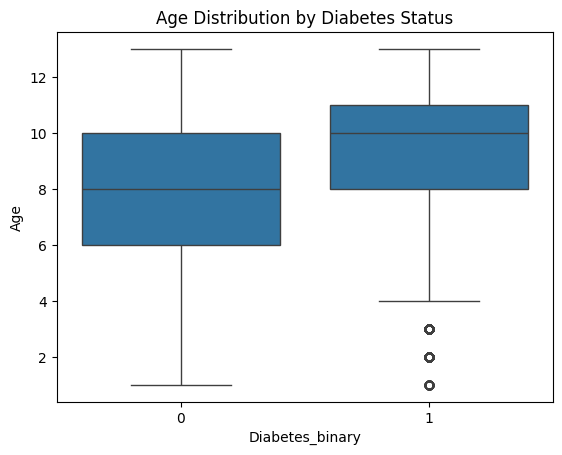

In [ ]:
# Analyze relationship between Age and diabetes
# This plot compares the distribution of age categories
# between individuals with and without diabetes risk.

# Boxplot comparing Age across diabetes classes
sns.boxplot(x='Diabetes_binary', y='Age', data=df)

# Add title
plt.title("Age Distribution by Diabetes Status")

# Display plot
plt.show()

**Interpretation**

Individuals with diabetes tend to fall into higher age categories compared to those without diabetes. The median age for the diabetes group is higher, and the distribution is shifted upward overall.

This indicates that age is an important factor in diabetes risk. However, since age is encoded in categories rather than exact values, the interpretation reflects relative age group differences rather than precise age differences.

The presence of some lower-age outliers in the diabetes group suggests that while age is a strong factor, diabetes can still occur in younger individuals.

## Physical Activity and Diabetes

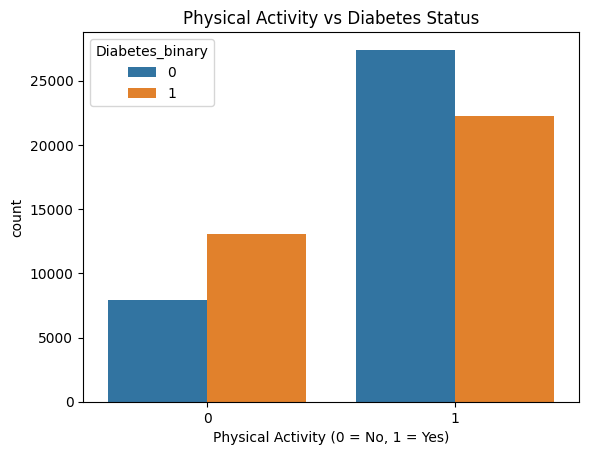

In [ ]:
# Analyze physical activity vs diabetes

# This plot compares the number of individuals who report
# physical activity (1) vs no physical activity (0),
# separated by diabetes status.


# Countplot with hue to compare diabetes status
sns.countplot(x='PhysActivity', hue='Diabetes_binary', data=df)

# Adds title
plt.title("Physical Activity vs Diabetes Status")

# Adds x-axis label
plt.xlabel("Physical Activity (0 = No, 1 = Yes)")

# Displays plot
plt.show()

**Interpretation**

The plot shows that individuals who report no physical activity (PhysActivity = 0) have a higher proportion of diabetes compared to those who are physically active. While both groups contain individuals with and without diabetes, the relative frequency of diabetes is noticeably higher among those who are inactive.

This suggests that physical inactivity is associated with increased diabetes risk. However, since a substantial number of physically active individuals also have diabetes, physical activity alone is not sufficient to fully explain the outcome. This reinforces the need for models that consider multiple features simultaneously.

## High Blood Pressure and Diabetes

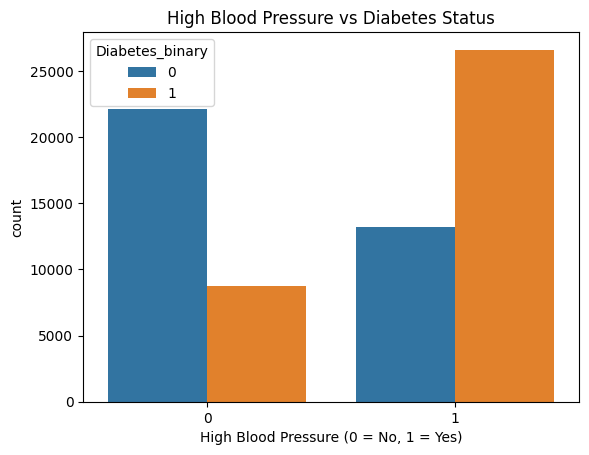

In [ ]:
# Analyze high blood pressure vs diabetes

# This plot compares individuals with and without high blood pressure,
# separated by diabetes status.
sns.countplot(x='HighBP', hue='Diabetes_binary', data=df)

# Adds title and x-axis lavel
plt.title("High Blood Pressure vs Diabetes Status")
plt.xlabel("High Blood Pressure (0 = No, 1 = Yes)")

# Shows plot
plt.show()

**Interpretation**

The distribution shows a strong association between high blood pressure and diabetes. Individuals with high blood pressure (HighBP = 1) are much more likely to have diabetes compared to those without high blood pressure.

In contrast, among individuals without high blood pressure, the majority do not have diabetes. This indicates that high blood pressure is one of the strongest predictors observed so far and is likely to play an important role in the classification model.

## General Health and Diabetes

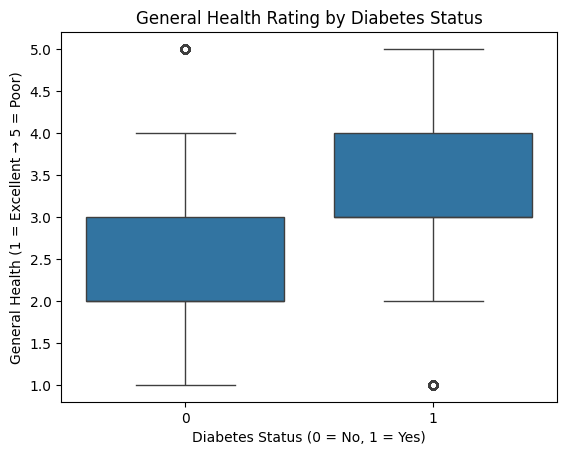

In [ ]:
# Analyze general health (ordinal) vs diabetes

# GenHlth is an ordinal variable:
# 1 = Excellent, 2 = Very Good, 3 = Good, 4 = Fair, 5 = Poor

# This plot shows how general health ratings differ
# between individuals with and without diabetes.
sns.boxplot(x='Diabetes_binary', y='GenHlth', data=df)


# Add labels and title
plt.title("General Health Rating by Diabetes Status")
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)")
plt.ylabel("General Health (1 = Excellent → 5 = Poor)")

# Displays plot
plt.show()

**Interpretation**

The distribution shows that individuals with diabetes tend to report worse general health compared to those without diabetes. The median for the diabetes group is higher (closer to “fair” or “poor”), while the non-diabetes group is centered around better health ratings.

There is also a noticeable upward shift in the entire distribution for individuals with diabetes, indicating that poorer self-reported health is strongly associated with diabetes status. This aligns with earlier findings (BMI, HighBP), reinforcing that diabetes is closely tied to overall health condition rather than a single isolated factor.

## Correlation Analysis

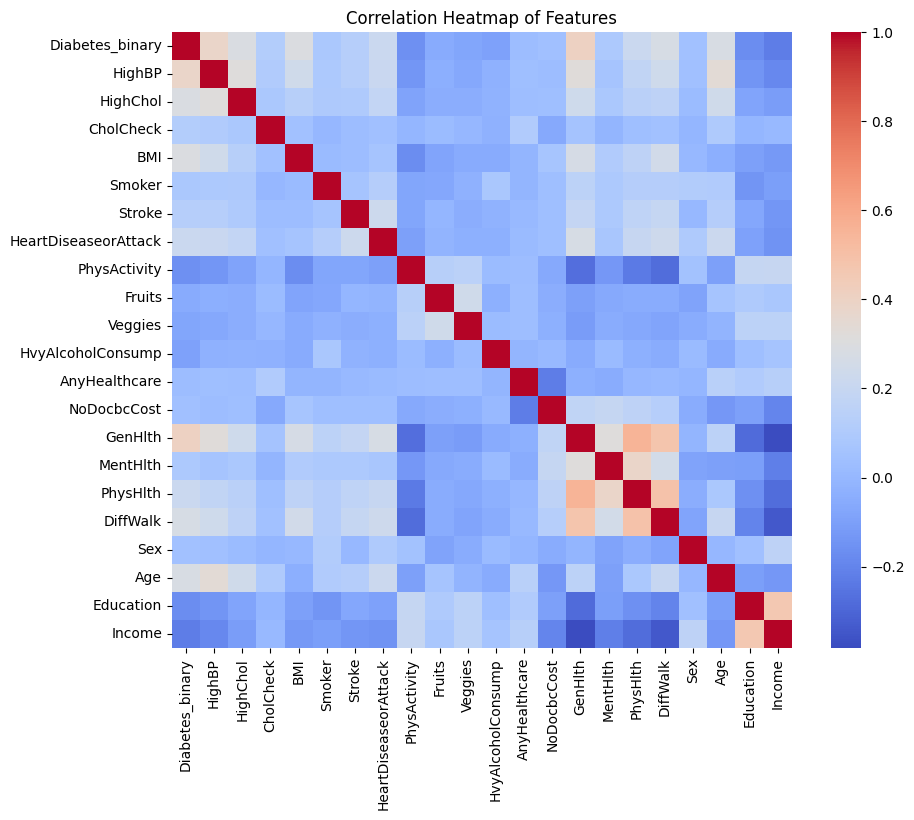

In [ ]:
# Correlation heatmap

# Compute correlation matrix
corr_matrix = df.corr()

# Plots heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='coolwarm')

plt.title("Correlation Heatmap of Features")

# Displays plot
plt.show()

**Interpretation**

The heatmap shows the pairwise correlations between all variables in the dataset.

Key observations:

Diabetes_binary shows moderate positive correlations with:

*   HighBP
*   BMI
*   GenHlth
*   Age

There are also noticeable relationships among health-related variables:
GenHlth, PhysHlth, and DiffWalk are

*   GenHlth, PhysHlth, and DiffWalk are positively correlated, suggesting they capture related aspects of overall health condition
*   Income and Education show positive correlation, reflecting socioeconomic structure

Most correlations are relatively low, indicating that no single feature dominates prediction.

## EDA Summary

The exploratory data analysis reveals several patterns associated with diabetes. Individuals with diabetes tend to have higher BMI, are older, are more likely to have high blood pressure, and report worse general health. Behavioral factors such as physical activity also show an association, with inactive individuals exhibiting higher rates of diabetes.

While several variables demonstrate clear relationships with diabetes, none alone is sufficient to fully explain the outcome. The correlation heatmap further supports this, showing that most features have only moderate or weak pairwise correlations with the target variable.

Overall, these findings suggest that diabetes is influenced by a combination of demographic, behavioral, and clinical factors. This motivates the use of k-nearest neighbors for classification and k-means for clustering, to capture these multivariate relationships and improve predictive performance.

## Data Science Lifecycle Phase 3: Modeling Preparation

In this phase, we move from exploratory data analysis into model development. The goal is to use the health indicators from the BRFSS dataset to predict diabetes status and then test whether k-Means cluster labels improve kNN classification performance.

To avoid data leakage, we split the data into training and testing sets before fitting any scaler, clustering model, or classifier. This matters because the test set should represent unseen data. Any preprocessing step that learns from the full dataset before the split would allow information from the test set to influence the model.

In [ ]:
# -----------------------------------
# Separate features and target variable
# -----------------------------------

# X contains all predictor variables.
# y contains the diabetes outcome.
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# -----------------------------------
# Train/test split
# -----------------------------------

# We split the data before scaling or clustering to avoid data leakage.
# stratify=y keeps the diabetes/no-diabetes balance consistent in both sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Confirm the split sizes.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

## Model 1: Baseline kNN Without Clusters

The first model is a baseline kNN classifier using the original 21 health indicators. This gives us a starting point before tuning or adding cluster information.

In [ ]:
# -----------------------------------
# Model 1: Baseline kNN without clusters
# -----------------------------------

# kNN is distance-based, so the features must be scaled.
# The pipeline ensures that scaling is fit only on the training data.
knn_baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Fit the baseline model on the training data.
knn_baseline_pipeline.fit(X_train, y_train)

# Predict diabetes status for the test data.
y_pred_baseline = knn_baseline_pipeline.predict(X_test)

# Evaluate baseline model performance.
print("Model 1: Baseline kNN Without Clusters")
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("
Classification Report:")
print(classification_report(y_test, y_pred_baseline))

# Display confusion matrix for the baseline model.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_baseline)
plt.title("Confusion Matrix - Baseline kNN Without Clusters")
plt.show()

## Model 2: Tuned kNN Without Clusters

The second model tunes the kNN classifier by testing different values for the number of neighbors and the weighting method. This supports the rubric requirement to show a training and tuning process instead of relying on one default model.

In [ ]:
# -----------------------------------
# Model 2: Tuned kNN without clusters
# -----------------------------------

# This pipeline scales the predictors and then fits kNN.
knn_tuned_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Hyperparameter grid for kNN.
# n_neighbors controls how many nearby points vote.
# weights controls whether all neighbors count equally or closer neighbors count more.
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 11, 15, 21],
    'knn__weights': ['uniform', 'distance']
}

# GridSearchCV tunes the model using only the training data.
# cv=3 is used to keep runtime reasonable in Google Colab.
grid_search = GridSearchCV(
    knn_tuned_pipeline,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the grid search on the training data.
grid_search.fit(X_train, y_train)

# Print the best tuning results.
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Accuracy:", grid_search.best_score_)

# Use the best tuned model to predict on the test data.
best_knn_model = grid_search.best_estimator_
y_pred_tuned = best_knn_model.predict(X_test)

# Evaluate tuned kNN model performance.
print("
Model 2: Tuned kNN Without Clusters")
print("Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("
Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# Display confusion matrix for tuned model.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.title("Confusion Matrix - Tuned kNN Without Clusters")
plt.show()

## Model 3: k-Means Clustering

The third model uses k-Means clustering to identify groups of individuals with similar health profiles. Because k-Means is distance-based, features are scaled before clustering. The scaler and k-Means model are fit only on the training data to avoid data leakage.

In [ ]:
# -----------------------------------
# Prepare scaled data for k-Means
# -----------------------------------

# Create a separate scaler for clustering.
# This scaler is fit only on the training features.
kmeans_scaler = StandardScaler()

# Fit on training data and transform training data.
X_train_scaled = kmeans_scaler.fit_transform(X_train)

# Transform the test data using the training scaler.
X_test_scaled = kmeans_scaler.transform(X_test)

### Elbow Plot

The elbow plot helps us choose a reasonable number of clusters by comparing inertia values across different values of k. Inertia measures the total squared distance between points and their assigned cluster centers.

In [ ]:
# -----------------------------------
# Elbow method for selecting k
# -----------------------------------

# Create an empty list to store inertia values.
inertias = []

# Test possible cluster values from 2 through 9.
k_values = range(2, 10)

# Fit k-Means for each k and store the inertia.
# This is done only on the training data to avoid data leakage.
for k in k_values:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans_temp.fit(X_train_scaled)
    inertias.append(kmeans_temp.inertia_)

# Plot the elbow curve.
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')

plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Selecting Number of Clusters')

plt.show()

**Elbow Plot Interpretation**

As the number of clusters increases, inertia decreases because each cluster becomes smaller and points are closer to their assigned cluster center. The goal is not to choose the lowest inertia automatically, but to choose a value of k where adding more clusters gives smaller improvements.

Based on the elbow plot, we selected **k = 8** because the decrease in inertia begins to slow around this point. This gives us multiple health-risk profiles while still keeping the clustering model interpretable.

### Final k-Means Model With 8 Clusters

In [ ]:
# -----------------------------------
# Final k-Means model with k = 8
# -----------------------------------

# Fit the final k-Means model only on the scaled training data.
kmeans_final = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

# Assign clusters to training data.
train_clusters = kmeans_final.fit_predict(X_train_scaled)

# Assign clusters to test data using the trained k-Means model.
test_clusters = kmeans_final.predict(X_test_scaled)

# Store scaled training and test features in DataFrames for interpretation.
X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Add cluster labels to the scaled training and test DataFrames.
X_train_scaled_df['Diabetes_clusters'] = train_clusters
X_test_scaled_df['Diabetes_clusters'] = test_clusters

# Check cluster sizes in the training data.
print("Training Cluster Sizes:")
print(X_train_scaled_df['Diabetes_clusters'].value_counts().sort_index())

### Cluster Interpretation

Instead of interpreting the raw scaled cluster centers directly, we summarize each cluster using the original feature values. This makes the clusters easier to explain in terms of BMI, high blood pressure, physical activity, general health, and diabetes rate.

In [ ]:
# -----------------------------------
# Interpret clusters using original feature values
# -----------------------------------

# Create a copy of the original training data.
# Add each person's assigned cluster and diabetes outcome.
cluster_summary = X_train.copy()
cluster_summary['Diabetes_clusters'] = train_clusters
cluster_summary['Diabetes_binary'] = y_train

# Calculate the mean value of each feature within each cluster.
cluster_means = cluster_summary.groupby('Diabetes_clusters').mean()

# Focus on features that were important in EDA.
important_cluster_features = [
    'BMI',
    'HighBP',
    'HighChol',
    'PhysActivity',
    'GenHlth',
    'Age',
    'DiffWalk',
    'Diabetes_binary'
]

# Display the cluster profiles for interpretation.
cluster_means[important_cluster_features]

**Cluster Interpretation Notes**

The cluster summary table should be interpreted as a set of health-risk profiles. For example, clusters with higher average BMI, higher rates of high blood pressure, worse general health ratings, and higher diabetes rates can be understood as higher-risk profiles. Clusters with lower BMI, lower rates of high blood pressure, better general health, and lower diabetes rates can be understood as lower-risk profiles.

This clustering step supports the project question by showing whether individuals naturally group into meaningful health profiles before we add the cluster labels to the prediction model.

### Cluster Visualization

The 3D visualization uses three features that were important in EDA: HighBP, BMI, and GenHlth. To make the plot readable, we sample up to 500 observations from each cluster.

In [ ]:
# -----------------------------------
# 3D visualization of k-Means clusters
# -----------------------------------

# Create a visualization DataFrame using scaled training data.
cluster_viz = X_train_scaled_df.copy()

# Add diabetes outcome for possible reference.
cluster_viz['Diabetes_binary'] = y_train.values

# Sample up to 500 observations from each cluster.
# This prevents the 3D plot from becoming too crowded.
cluster_viz_sample = cluster_viz.groupby(
    'Diabetes_clusters',
    group_keys=False
).apply(
    lambda x: x.sample(min(len(x), 500), random_state=42)
)

# Create a 3D scatter plot of the clusters.
fig = px.scatter_3d(
    cluster_viz_sample,
    x='HighBP',
    y='BMI',
    z='GenHlth',
    color=cluster_viz_sample['Diabetes_clusters'].astype(str),
    title='K-Means Clustering of Diabetes Risk Profiles',
    labels={'color': 'Cluster'},
    opacity=0.5
)

fig.show()

## Model 4: Tuned kNN With k-Means Cluster Feature

The final model tests whether adding k-Means cluster membership improves kNN prediction. The cluster labels are created only from the training-fitted k-Means model, then added to the training and test sets.

In [ ]:
# -----------------------------------
# Prepare cluster-enhanced data for kNN
# -----------------------------------

# Start with the original unscaled features.
X_train_with_clusters = X_train.copy()
X_test_with_clusters = X_test.copy()

# Add the k-Means cluster labels as a new feature.
X_train_with_clusters['Diabetes_clusters'] = train_clusters
X_test_with_clusters['Diabetes_clusters'] = test_clusters

# Confirm the new feature was added.
print("Training data with clusters:", X_train_with_clusters.shape)
print("Test data with clusters:", X_test_with_clusters.shape)

In [ ]:
# -----------------------------------
# Model 4: Tuned kNN with cluster labels
# -----------------------------------

# Use the same best kNN settings found during tuning.
# The pipeline scales the original features plus the cluster feature.
knn_cluster_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=grid_search.best_params_['knn__n_neighbors'],
        weights=grid_search.best_params_['knn__weights']
    ))
])

# Fit the cluster-enhanced kNN model on training data only.
knn_cluster_pipeline.fit(X_train_with_clusters, y_train)

# Predict diabetes status on the test data.
y_pred_clustered = knn_cluster_pipeline.predict(X_test_with_clusters)

# Evaluate the cluster-enhanced model.
print("Model 4: Tuned kNN With k-Means Cluster Feature")
print("Accuracy:", accuracy_score(y_test, y_pred_clustered))
print("
Classification Report:")
print(classification_report(y_test, y_pred_clustered))

# Display confusion matrix.
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_clustered)
plt.title("Confusion Matrix - Tuned kNN With Clusters")
plt.show()

## Model Comparison

This table compares the baseline kNN model, the tuned kNN model, and the tuned kNN model with k-Means cluster membership added as a feature.

In [ ]:
# -----------------------------------
# Compare model accuracy
# -----------------------------------

# Calculate accuracy for each model.
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
clustered_accuracy = accuracy_score(y_test, y_pred_clustered)

# Create a results table.
model_results = pd.DataFrame({
    'Model': [
        'Model 1: Baseline kNN',
        'Model 2: Tuned kNN',
        'Model 4: Tuned kNN + k-Means Clusters'
    ],
    'Accuracy': [
        baseline_accuracy,
        tuned_accuracy,
        clustered_accuracy
    ]
})

# Display model comparison.
model_results

In [ ]:
# -----------------------------------
# ROC-AUC comparison
# -----------------------------------

# Get predicted probabilities for the positive class.
y_prob_baseline = knn_baseline_pipeline.predict_proba(X_test)[:, 1]
y_prob_tuned = best_knn_model.predict_proba(X_test)[:, 1]
y_prob_clustered = knn_cluster_pipeline.predict_proba(X_test_with_clusters)[:, 1]

# Calculate ROC-AUC scores.
baseline_auc = roc_auc_score(y_test, y_prob_baseline)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)
clustered_auc = roc_auc_score(y_test, y_prob_clustered)

# Display AUC scores.
print("Baseline kNN ROC-AUC:", baseline_auc)
print("Tuned kNN ROC-AUC:", tuned_auc)
print("Tuned kNN + Clusters ROC-AUC:", clustered_auc)

**Modeling Interpretation**

The baseline kNN model provides an initial benchmark for predicting diabetes status using the original health indicators. The tuned kNN model improves the process by testing different values of k and weighting methods through cross-validation.

The k-Means model identifies health-risk profiles based on patterns across the predictor variables. Adding these cluster labels to the kNN model allows us to test whether cluster membership provides additional predictive information.

If the cluster-enhanced model performs better than the tuned kNN model, this suggests that cluster membership adds useful information beyond the original variables. If the improvement is small, this suggests that the original features already capture most of the predictive signal, while the clusters remain useful for interpretation.